You could use this notebook on [Google Colab](https://colab.research.google.com/) with a GPU Hardware Accelerator runtype.

# RAW DATA
Install dependencies and retrieve all games from 1983-present using the nba_api library. The API library limits the size of each individual request. To warehouse my final dataset I will request each season's games separately then concatenate the responses together into one dataframe.


In [15]:
#For some reason pip3 install -r requirements.txt doesn't work on Colab
! pip3 install -r requirements.txt


[notice] A new release of pip available: 22.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
from nba_api.stats.endpoints import teamgamelog, cumestatsteamgames, cumestatsteam, gamerotation, boxscoreadvancedv3, leaguegamefinder
from nba_api.stats.static import teams, players
import matplotlib.pyplot as plt
import seaborn as sns
import json

pd.option_context('mode.chained_assignment', None)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [17]:
def get_season(season: str) -> pd.DataFrame:
    # Input: season string with format '2011-12'
    # Output: pandas dataframe of all regular season games in the NBA for that season
    result = leaguegamefinder.LeagueGameFinder(league_id_nullable='00', season_type_nullable='Regular Season', season_nullable=season)
    season_games = result.get_data_frames()[0]
    return season_games

all_seasons = []
for start_year in range(1983, 2025):
    end_year_suffix = (start_year + 1) % 100 # last two digits of end year
    season_str = f'{start_year}-{end_year_suffix:02d}'
    print(season_str)
    season_df = get_season(season_str)
    all_seasons.append(season_df)

all_games = pd.concat(all_seasons, ignore_index=True)


1983-84
1984-85
1985-86
1986-87
1987-88
1988-89
1989-90
1990-91
1991-92
1992-93
1993-94
1994-95
1995-96
1996-97
1997-98
1998-99
1999-00
2000-01
2001-02
2002-03
2003-04
2004-05
2005-06
2006-07
2007-08
2008-09
2009-10
2010-11
2011-12
2012-13
2013-14
2014-15
2015-16
2016-17
2017-18
2018-19
2019-20
2020-21
2021-22
2022-23
2023-24
2024-25


C:\Users\order\AppData\Local\Temp\ipykernel_10272\1419962783.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_games = pd.concat(all_seasons, ignore_index=True)


# DATA UNDERSTANDING
A key to the usefulness of this program is understanding the dataset. Knowing the limitations of the current data adds context to the predictions made by the program. This dataset contains 95,774 games with 20 numerical attributes and seven categorical attributes. The categorical attributes are mostly IDs for identifying the season, team, game, and date. The dataset is relatively clean to start, the only missing values are PLUS_MINUS prior to the 1996 season. 

In [18]:
# Plus-minus was not included until the 1996 season resulting in NaN values for all prior seasons
# could just remove those seasons
print(all_games.columns)
print(f'Total games: {len(all_games)}')

Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB',
       'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS'],
      dtype='object')
Total games: 95774


## Feature Definitions

Each row represents one team's statistics for a game. The other team in the matchup is represented in a different row  
TEAM_NAME: Name of the home team.  
MIN: total minutes logged by players. Will generally   
FGM: Made field goals  
FGA: total attempted field goals  
FG_PCT: percentage of field goals made  
FG3M: three point field goals made  
FG3A: three point field goals attempted  
FG3_PCT: percentage of three point field goals made  
FTM: free throws made  
FTA: free throws attempted   
FT_PCT: percentage of free throws made  
OREB: offensive rebounds  
DREB: defensive rebounds  
REB: total rebounds  
AST: assists  
TOV: turnovers  
STL: steals  
BLK: blocks  
PF: personal fouls   
PTS: total points  
PLUS_MINUS: point differential 

In [19]:
# make season ID more readable
all_games['SEASON_ID'] = all_games['SEASON_ID'].apply(lambda x: x[1:])

In [20]:
# Example matchup
all_games[(all_games['SEASON_ID']=='2024')&(all_games['TEAM_ABBREVIATION']=='BOS')]['TOV'].mean()

11.353658536585366

Max points: 186
Min points: 49


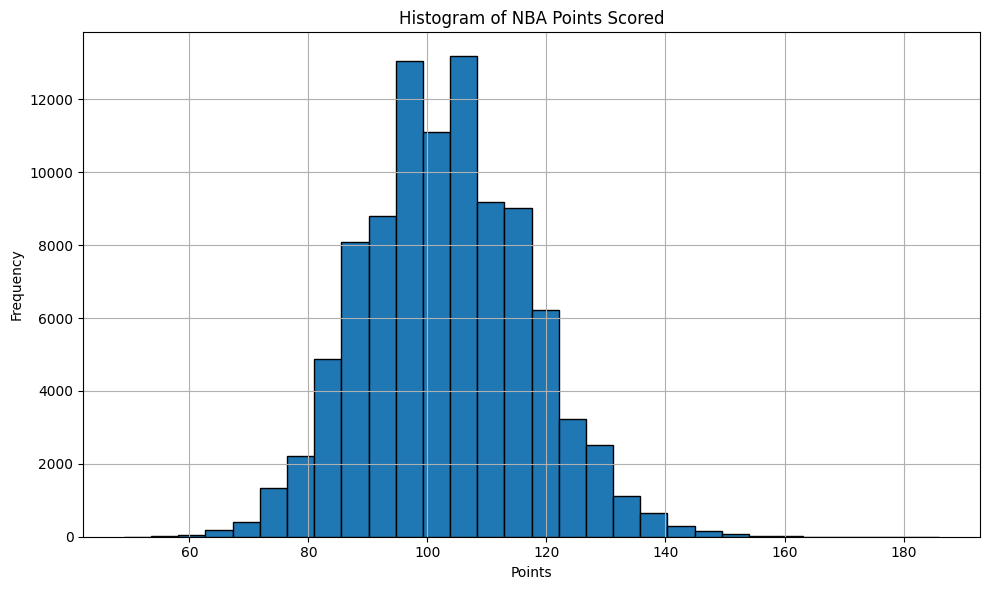

In [21]:
# Plot histogram for 'PTS' column
print(f"Max points: {all_games['PTS'].max()}")
print(f"Min points: {all_games['PTS'].min()}")
plt.figure(figsize=(10, 6))
plt.hist(all_games['PTS'].dropna(), bins=30, edgecolor='black')  # Drop NaN values for cleaner data
plt.title('Histogram of NBA Points Scored')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

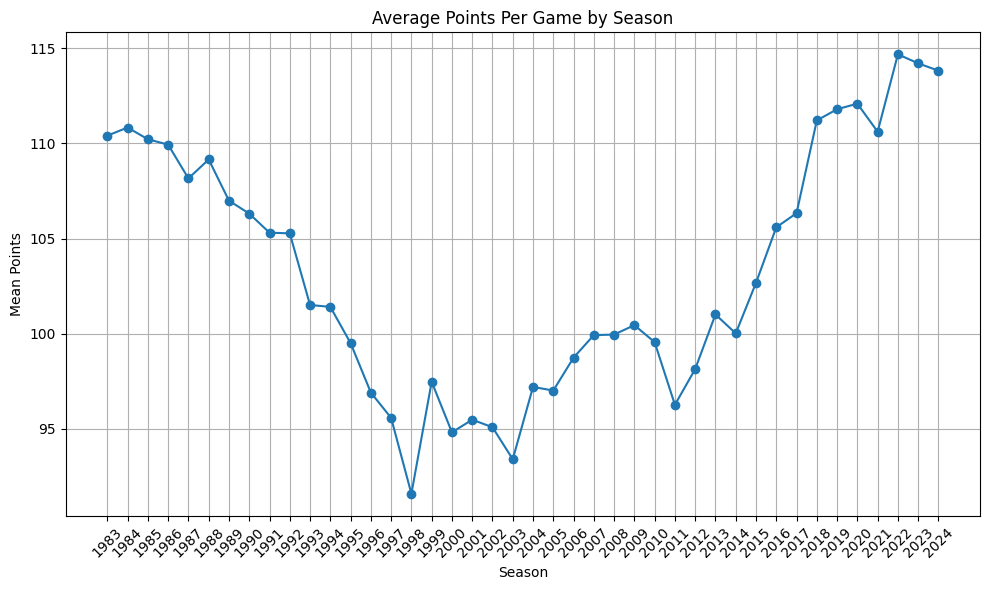

In [22]:
# Compute mean points per season
mean_pts_per_season = all_games.groupby('SEASON_ID')['PTS'].mean().reset_index()
mean_pts_per_season.columns = ['SEASON_ID', 'Mean_PTS']

# plot the result
plt.figure(figsize=(10, 6))
plt.plot(mean_pts_per_season['SEASON_ID'], mean_pts_per_season['Mean_PTS'], marker='o')

plt.title('Average Points Per Game by Season')
plt.xlabel('Season')
plt.ylabel('Mean Points')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(True)
plt.tight_layout()
plt.show()

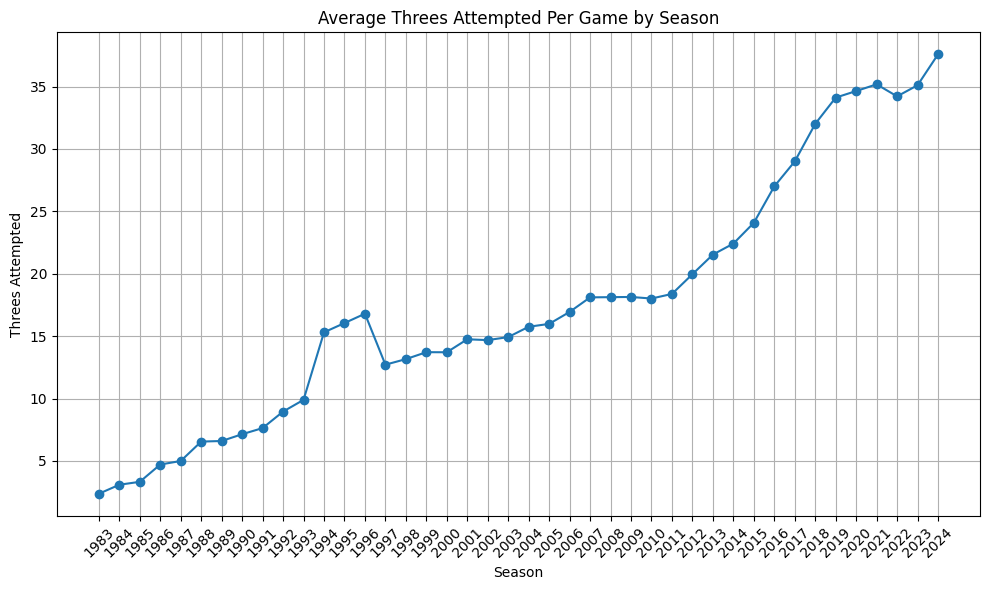

In [23]:
# Compute average 3-point field goals made and plot change over time
mean_pts_per_season = all_games.groupby('SEASON_ID')['FG3A'].mean().reset_index()
mean_pts_per_season.columns = ['SEASON_ID', 'Mean_FG3A']

# plot the result
plt.figure(figsize=(10, 6))
plt.plot(mean_pts_per_season['SEASON_ID'], mean_pts_per_season['Mean_FG3A'], marker='o')

plt.title('Average Threes Attempted Per Game by Season')
plt.xlabel('Season')
plt.ylabel('Threes Attempted')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(True)
plt.tight_layout()
plt.show()

## Trends
We can see a decrease a steady decrease in points year-over-year until the 1998 season. This decrease could be attributed to a greater emphasis on defense and physical play. The 1998 season was shortened to 50 games due to a lockout leading to less preparation time and lower scoring. Several rule changes including defensive three-second violations and a hand-checking prohibition resulted in more offensive freedom and scoring. The most dramatic effect on overall scoring, however, is the three-point revolution. Teams have place a strategic emphasis on three point scoring resulting in an increase from less than 3 threes attempted per game in the 80s to over 30 today.

Since points is the label my models will predict I spent the most time trying to understand this feature. Points scored follows a relatively normal distribution as can be seen from the histogram

# DATA CLEANING
As can be seen in the correlation matrix some attributes are highly correlated with each other. For example, free throws made are highly correlated with free throws attempted since the percentage made is relatively stable across the league. While shot attempts is highly correlated with shot makes attempts capture important information about a team's pace of play and shot selection which both influence total points. Attempts and makes represent complementary, not redundant, attributes and both will be retained for training the dataset.

There are, however, some derived attributes in the dataset which represent redundant information. Shot percentage for all three types of shots (free throws, field goals, three-point field goals) can be derived from shots made / shots attempted so it can be dropped. Total rebounds also can be derived from offensive rebounds + defensive rebounds. Since it is less granular than the two individual rebound types it can also be dropped.

The final attribute which can be dropped is plus-minus. This statistic is more informative on the player level since it represents the point differential while that player is on the court. At the team level plus-minus will always be the point differential for the game, already reflected in the points attribute. This statistic was also not recorded until 1996 so rather than imputing missing values I will drop it entirely. 

# TODO
Normalize points. Maybe normalize other attributes?

In [24]:
all_games.drop(['FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'PLUS_MINUS'], axis=1, inplace=True)
all_games.columns

Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG3M',
       'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'PF'],
      dtype='object')

AT_HOME is a binary attribute. For the vast majority of games one team will be home and the other away. For a few internationally played games both teams are considered away. 

In [ ]:

game_ids = [
    "0022401230",
    "0022401229",
    "0022400633",
    "0022400621",
    "0022400147"
]
at_home_errors = all_games[all_games['GAME_ID'].isin(game_ids)]
at_home_errors.head(10)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF
94439,2024,1610612754,IND,Indiana Pacers,0022400633,2025-01-25,IND @ SAS,W,240,136,53,102,17,39.0,13,14,16.0,34.0,32,14.0,9,10,20
94440,2024,1610612759,SAS,San Antonio Spurs,0022400633,2025-01-25,IND @ SAS,L,241,98,35,85,11,32.0,17,25,15.0,29.0,22,9.0,5,22,17
94472,2024,1610612754,IND,Indiana Pacers,0022400621,2025-01-23,SAS @ IND,L,242,110,44,97,13,43.0,9,12,9.0,22.0,31,10.0,2,11,9
94482,2024,1610612759,SAS,San Antonio Spurs,0022400621,2025-01-23,SAS @ IND,W,241,140,58,96,18,36.0,6,6,15.0,42.0,43,10.0,10,19,13
95022,2024,1610612760,OKC,Oklahoma City Thunder,0022401230,2024-12-14,HOU @ OKC,W,241,111,36,80,11,30.0,28,32,4.0,39.0,19,12.0,4,12,24
95023,2024,1610612745,HOU,Houston Rockets,0022401230,2024-12-14,HOU @ OKC,L,240,96,35,96,11,46.0,15,25,19.0,30.0,17,7.0,3,16,25
95024,2024,1610612749,MIL,Milwaukee Bucks,0022401229,2024-12-14,ATL @ MIL,W,239,110,39,86,14,45.0,18,27,6.0,41.0,28,8.0,8,12,27
95025,2024,1610612737,ATL,Atlanta Hawks,0022401229,2024-12-14,ATL @ MIL,L,241,102,35,82,10,24.0,22,34,7.0,37.0,23,3.0,6,13,20
95600,2024,1610612748,MIA,Miami Heat,0022400147,2024-11-02,MIA @ WAS,W,240,118,43,102,15,37.0,17,24,21.0,44.0,19,6.0,3,13,18
95602,2024,1610612764,WAS,Washington Wizards,0022400147,2024-11-02,MIA @ WAS,L,240,98,38,91,7,35.0,15,21,8.0,36.0,23,12.0,10,11,22


In [95]:
all_games.iloc[94439]

SEASON_ID                           2024
TEAM_ID                       1610612754
TEAM_ABBREVIATION                    IND
TEAM_NAME                 Indiana Pacers
GAME_ID                       0022400633
GAME_DATE            2025-01-25 00:00:00
MATCHUP                        IND @ SAS
WL                                     W
MIN                                  240
PTS                                  136
FGM                                   53
FGA                                  102
FG3M                                  17
FG3A                                39.0
FTM                                   13
FTA                                   14
OREB                                16.0
DREB                                34.0
AST                                   32
STL                                 14.0
BLK                                    9
TOV                                   10
PF                                    20
Name: 94439, dtype: object

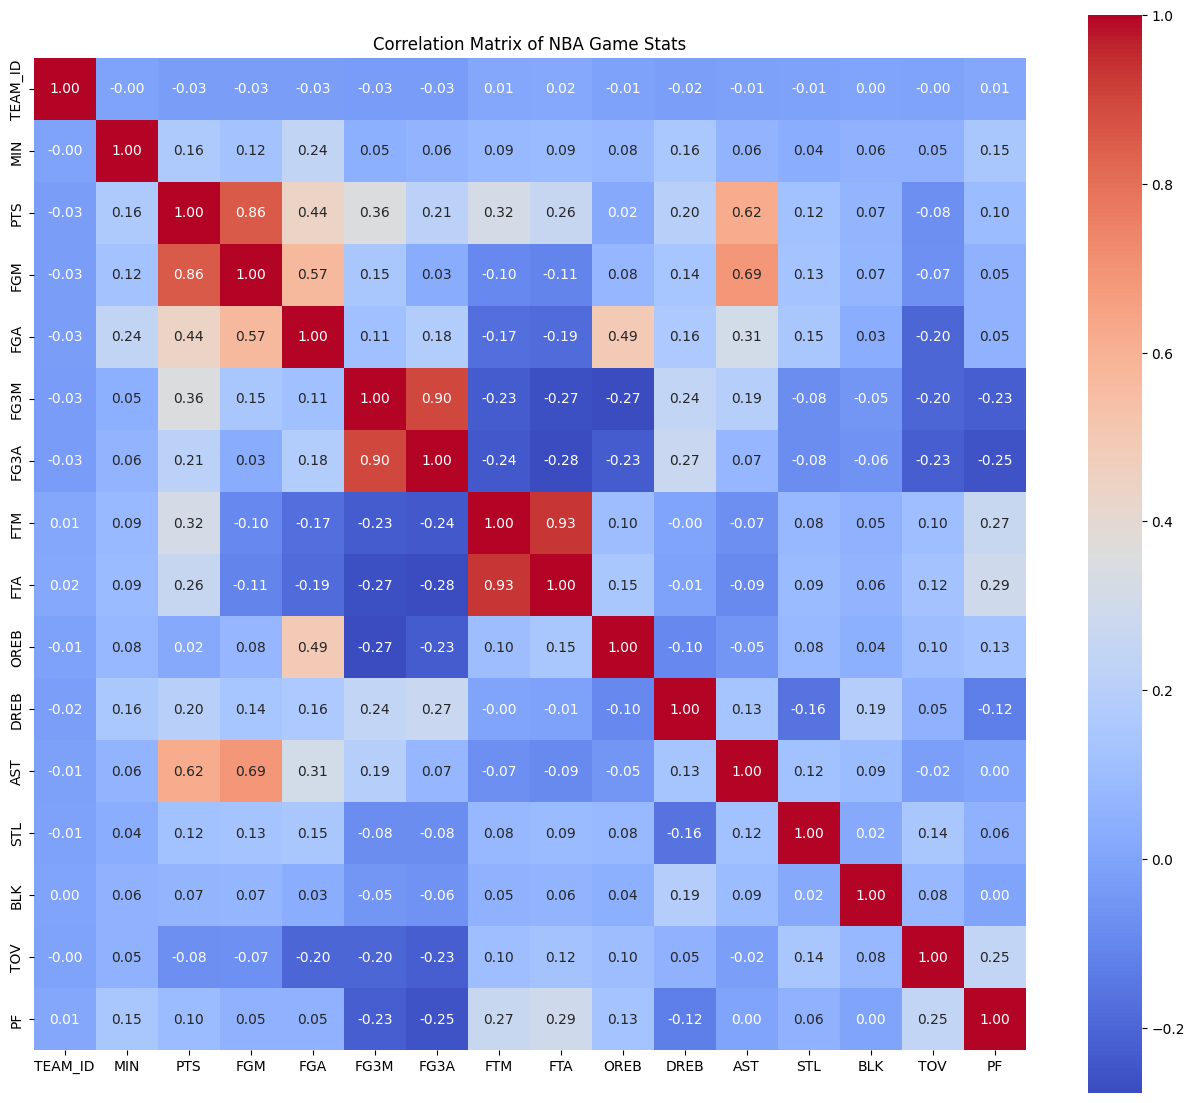

In [25]:
correlation_matrix = all_games.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Matrix of NBA Game Stats")
plt.show()

In [26]:
# sort games by date and ID to group matchups together
all_games['GAME_DATE'] = pd.to_datetime(all_games['GAME_DATE'], format='%Y-%m-%d')
sorted_games = all_games.sort_values(['GAME_DATE', 'GAME_ID'], ascending=True)
sorted_games.tail(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF
93320,2024,1610612758,SAC,Sacramento Kings,0022401200,2025-04-13,SAC vs. PHX,W,243,109,46,88,14,34.0,3,3,10.0,33.0,31,6.0,4,11,7
93321,2024,1610612756,PHX,Phoenix Suns,0022401200,2025-04-13,PHX @ SAC,L,241,98,40,84,15,44.0,3,6,9.0,28.0,28,6.0,1,11,9


# DATA MODELING  

### Feedforward Neural Network
Next, I will train a feedforward neural network. For features I will use a team's average statistics and the matchup's average statistics for the season. The label used will be points scored. I do not plan on standardizing statistics from different seasons to a common distribution like with the Markov Chain Model. Standardization would lead to consistency across eras but reduce the interpretability of the model. This consistency is not as important for a neural network as a transition model. 

In [32]:
sorted_games.head(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF
1870,1983,1610612754,IND,Indiana Pacers,0028300001,1983-10-28,IND @ MIL,L,240,83,35,104,0,0.0,13,21,24.0,29.0,27,7.0,4,19,22
1877,1983,1610612749,MIL,Milwaukee Bucks,0028300001,1983-10-28,MIL vs. IND,W,240,104,42,97,0,1.0,20,26,21.0,39.0,24,12.0,13,19,22


In [ ]:
# Convert MATCHUP column to binary AT_HOME
sorted_games['AT_HOME'] = sorted_games['MATCHUP'].str.contains('vs')

at_home_df = sorted_games.drop(['MATCHUP'], axis=1)
at_home_df.head(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME
1870,1983,1610612754,IND,Indiana Pacers,0028300001,1983-10-28,L,240,83,35,104,0,0.0,13,21,24.0,29.0,27,7.0,4,19,22,False
1877,1983,1610612749,MIL,Milwaukee Bucks,0028300001,1983-10-28,W,240,104,42,97,0,1.0,20,26,21.0,39.0,24,12.0,13,19,22,True


In [34]:
sorted_games['AT_HOME'] = sorted_games['AT_HOME'].astype(int)

In [35]:
games_rest = sorted_games.sort_values(['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)
games_rest['DAYS_REST'] = games_rest.groupby('TEAM_ID')['GAME_DATE'].diff().dt.days
games_rest['DAYS_REST'] = games_rest['DAYS_REST'].clip(upper=7)
games_rest.head()


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME,DAYS_REST
0,1983,1610612737,ATL,Atlanta Hawks,0028300005,1983-10-28,L,240,108,41,90,0,0.0,26,38,15.0,18.0,14,10.0,5,17,30,0,NaN
1,1983,1610612737,ATL,Atlanta Hawks,0028300014,1983-10-29,W,240,117,49,94,0,1.0,19,30,27.0,21.0,28,14.0,7,23,35,1,1.0
2,1983,1610612737,ATL,Atlanta Hawks,0028300027,1983-11-01,W,240,95,38,81,0,0.0,19,30,12.0,29.0,20,7.0,10,16,34,1,3.0
3,1983,1610612737,ATL,Atlanta Hawks,0028300041,1983-11-04,W,240,103,42,86,1,1.0,18,26,19.0,27.0,31,14.0,13,18,27,1,3.0
4,1983,1610612737,ATL,Atlanta Hawks,0028300058,1983-11-06,L,240,84,32,78,0,2.0,20,30,11.0,26.0,18,4.0,5,14,24,0,2.0


In [36]:
# First, make sure games are sorted
games = games_rest.sort_values(['TEAM_ABBREVIATION', 'SEASON_ID', 'GAME_DATE'])

# List of stats you want cumulative averages for
stat_columns = ['PTS', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'PF']

# Compute cumulative season averages
for stat in stat_columns:
    games[f'{stat}_season_avg'] = (
        games.groupby(['TEAM_ABBREVIATION', 'SEASON_ID'])[stat]
             .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
    )

In [37]:
games[games['SEASON_ID']=='2023'].head(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg
3207,2023,1610612737,ATL,Atlanta Hawks,0022300063,2023-10-25,L,240,110,39,93,5,29.0,27,33,12.0,30.0,24,12.0,1,12,19,0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3208,2023,1610612737,ATL,Atlanta Hawks,0022300079,2023-10-27,L,240,120,42,87,12,32.0,24,30,9.0,35.0,28,7.0,6,14,20,1,2.0,110.0,12.0,30.0,24.0,12.0,1.0,12.0,39.0,93.0,5.0,29.0,27.0,33.0,19.0


In [38]:
# Add opponent's season average statistics
# Get row with same game_id but different team_abbreviation
# Select the columns you want to merge from the opponent
opponent_cols = ['GAME_ID', 'TEAM_ABBREVIATION', 'PTS'] + [f'{stat}_season_avg' for stat in stat_columns]

# Rename columns to indicate opponent
opponent_data = games[opponent_cols].copy()
opponent_data = opponent_data.rename(columns={col: f'OPP_{col}' for col in opponent_cols if col != 'GAME_ID'})

In [39]:
# Step 2: Merge on GAME_ID
games_with_opponent = games.merge(opponent_data, on='GAME_ID', how='left')

# Step 3: Filter out where TEAM_ID == OPP_TEAM_ID (i.e., self matches)
games_with_opponent = games_with_opponent[games_with_opponent['TEAM_ABBREVIATION'] != games_with_opponent['OPP_TEAM_ABBREVIATION']]

In [40]:
games_with_opponent[games_with_opponent['GAME_ID']=='0022300097']

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_TEAM_ABBREVIATION,OPP_PTS,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg
6419,2023,1610612737,ATL,Atlanta Hawks,0022300097,2023-10-29,W,241,127,47,93,15,37.0,18,22,13.0,33.0,32,15.0,2,17,17,0,2.0,115.0,10.5,32.5,26.0,9.5,3.5,13.0,40.5,90.0,8.5,30.5,25.5,31.5,19.5,MIL,110,118.0,8.0,35.0,20.0,9.0,4.0,14.0,41.0,81.0,11.0,30.0,25.0,36.0,23.0
105038,2023,1610612749,MIL,Milwaukee Bucks,0022300097,2023-10-29,L,240,110,39,86,16,44.0,16,20,12.0,27.0,22,10.0,3,23,22,1,3.0,118.0,8.0,35.0,20.0,9.0,4.0,14.0,41.0,81.0,11.0,30.0,25.0,36.0,23.0,ATL,127,115.0,10.5,32.5,26.0,9.5,3.5,13.0,40.5,90.0,8.5,30.5,25.5,31.5,19.5


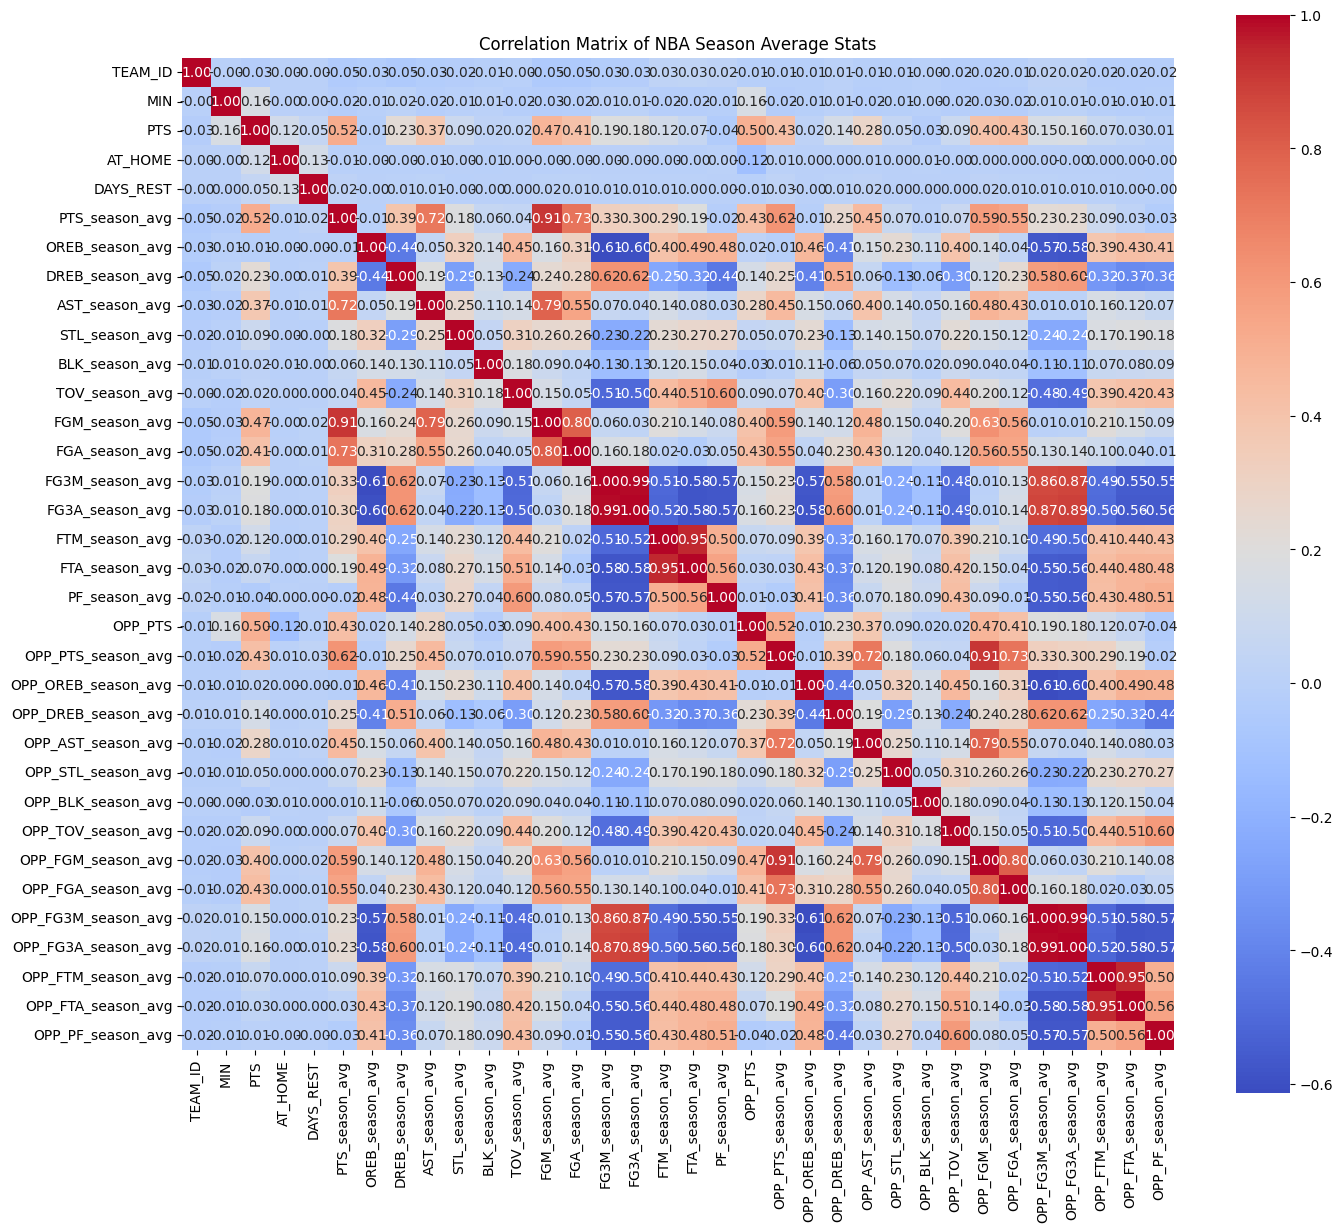

In [89]:
no_derived_df = games_with_opponent.drop(['OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'PF'], axis=1)
no_derived_df.dropna(subset=['PTS_season_avg', 'OPP_PTS_season_avg'], inplace=True)
correlation_matrix = no_derived_df.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Matrix of NBA Season Average Stats")
plt.show()

In [90]:
no_derived_df['PT_DIFF'] = no_derived_df['PTS'] - no_derived_df['OPP_PTS']
no_derived_df[no_derived_df['GAME_ID']=='0022401230']

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_TEAM_ABBREVIATION,OPP_PTS,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg,PT_DIFF
68279,2024,1610612745,HOU,Houston Rockets,0022401230,2024-12-14,L,240,96,0,3.0,112.720000,13.880000,35.480000,22.52,8.760000,5.640,12.560000,41.320000,93.920000,11.72,35.88,18.360,23.800000,20.240000,OKC,111,115.791667,10.666667,33.083333,26.00,12.166667,6.375,11.041667,43.208333,92.916667,14.00,40.00,15.375,19.083333,20.958333,-15
128816,2024,1610612760,OKC,Oklahoma City Thunder,0022401230,2024-12-14,W,241,111,0,4.0,115.791667,10.666667,33.083333,26.00,12.166667,6.375,11.041667,43.208333,92.916667,14.00,40.00,15.375,19.083333,20.958333,HOU,96,112.720000,13.880000,35.480000,22.52,8.760000,5.640,12.560000,41.320000,93.920000,11.72,35.88,18.360,23.800000,20.240000,15


In [ ]:
# Keep only the home team for each matchup, avoid duplicate games in dataset and better for comparison with sportsbook odds
sorted_df = home_only_df.sort_values(by=['GAME_ID', 'AT_HOME'], ascending=False)
home_only_df = sorted_df.drop_duplicates(subset=['GAME_ID'], keep='first')
home_only_df.head(5)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_TEAM_ABBREVIATION,OPP_PTS,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg,PT_DIFF
171026,1999,1610612760,SEA,Seattle SuperSonics,0029901189,2000-04-19,L,240,106,1,1.0,99.000000,12.703704,30.382716,22.851852,8.024691,4.172840,13.629630,37.827160,84.679012,6.641975,19.629630,16.703704,23.962963,21.666667,LAC,114,91.753086,11.543210,28.987654,17.950617,7.074074,6.037037,15.481481,35.012346,82.259259,5.148148,15.407407,16.580247,22.246914,22.283951,-8
150932,1999,1610612757,POR,Portland Trail Blazers,0029901188,2000-04-19,L,239,95,1,1.0,97.481481,11.790123,31.185185,23.469136,7.765432,4.814815,14.654321,36.851852,78.320988,4.975309,13.790123,18.802469,24.790123,22.827160,DEN,96,99.000000,13.160494,31.580247,23.296296,6.777778,7.518519,15.148148,37.234568,84.320988,5.728395,17.037037,18.802469,25.925926,23.975309,-1
57625,1999,1610612744,GSW,Golden State Warriors,0029901187,2000-04-19,L,239,88,1,2.0,95.629630,15.913580,29.765432,22.543210,8.864198,4.333333,15.296296,36.592593,87.111111,4.234568,13.074074,18.209877,26.098765,25.000000,PHX,99,98.913580,12.493827,31.074074,25.580247,9.074074,5.283951,16.098765,37.703704,82.654321,5.567901,15.246914,17.938272,23.654321,24.037037,-11
177714,1999,1610612762,UTA,Utah Jazz,0029901186,2000-04-19,W,240,95,1,1.0,96.530864,11.358025,29.530864,24.888889,7.641975,5.419753,14.086420,36.123457,77.728395,4.024691,10.419753,20.259259,26.246914,24.518519,SAC,86,105.197531,12.901235,32.197531,23.925926,9.617284,4.654321,15.728395,40.049383,89.000000,6.518519,20.246914,18.580247,24.617284,21.074074,9
164112,1999,1610612759,SAS,San Antonio Spurs,0029901185,2000-04-19,W,265,103,1,2.0,96.086420,11.308642,32.419753,22.123457,7.506173,6.753086,14.456790,35.938272,77.839506,4.000000,10.716049,20.209877,27.037037,20.901235,LAL,98,100.851852,13.518519,33.358025,23.432099,7.518519,6.555556,13.518519,38.222222,83.135802,4.197531,12.641975,20.209877,28.987654,22.456790,5


In [88]:
home_only_df[home_only_df['AT_HOME']==0]

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_TEAM_ABBREVIATION,OPP_PTS,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg,PT_DIFF
68279,2024,1610612745,HOU,Houston Rockets,0022401230,2024-12-14,L,240,96,0,3.0,112.720000,13.880000,35.480000,22.520000,8.760000,5.640000,12.560000,41.320000,93.920000,11.720000,35.880000,18.360000,23.800000,20.240000,OKC,111,115.791667,10.666667,33.083333,26.000000,12.166667,6.375000,11.041667,43.208333,92.916667,14.000000,40.000000,15.375000,19.083333,20.958333,-15
6631,2024,1610612737,ATL,Atlanta Hawks,0022401229,2024-12-14,L,241,102,0,3.0,116.730769,12.961538,33.423077,29.884615,10.076923,5.307692,15.269231,43.000000,93.230769,12.192308,35.961538,18.538462,23.730769,18.961538,MIL,110,113.416667,8.125000,34.583333,23.875000,7.125000,5.625000,13.416667,41.041667,84.625000,14.333333,36.500000,17.000000,23.208333,18.541667,-8
75069,2024,1610612754,IND,Indiana Pacers,0022400633,2025-01-25,W,240,136,0,2.0,115.045455,8.909091,32.681818,28.409091,8.250000,5.090909,12.840909,43.113636,88.204545,12.590909,33.954545,16.227273,21.045455,19.136364,SAS,98,112.309524,11.142857,34.595238,28.857143,7.452381,6.976190,14.023810,40.833333,88.952381,13.857143,39.857143,16.785714,21.166667,15.976190,38
75067,2024,1610612754,IND,Indiana Pacers,0022400621,2025-01-23,L,242,110,0,5.0,115.162791,8.906977,32.930233,28.348837,8.209302,5.162791,12.883721,43.093023,88.000000,12.581395,33.744186,16.395349,21.255814,19.372093,SAS,140,111.634146,11.048780,34.414634,28.512195,7.390244,6.902439,13.902439,40.414634,88.780488,13.756098,39.951220,17.048780,21.536585,16.048780,-30
98455,2024,1610612748,MIA,Miami Heat,0022400147,2024-11-02,W,240,118,0,3.0,106.000000,9.750000,32.000000,27.000000,8.250000,5.000000,10.750000,36.750000,84.250000,14.250000,38.750000,18.250000,25.250000,17.250000,WAS,98,118.000000,10.750000,30.750000,27.000000,8.000000,5.750000,15.000000,41.500000,92.750000,14.750000,40.250000,20.250000,24.250000,22.500000,20


In [58]:
# Train/test split
ff_train = home_only_df[(home_only_df['SEASON_ID'] != '2024') & (home_only_df['SEASON_ID']!='2023')]
ff_val = home_only_df[home_only_df['SEASON_ID'] == '2023']
ff_test = home_only_df[home_only_df['SEASON_ID'] == '2024']


# Features (your team and opponent rolling stats)
feature_cols = [col for col in home_only_df.columns if '_season_avg' in col]

# Target (what you want to predict)
target_col = 'PT_DIFF'

X_train = ff_train[feature_cols]
y_train = ff_train[target_col]

X_val = ff_val[feature_cols]
y_val = ff_val[target_col]

X_test = ff_test[feature_cols]
y_test = ff_test[target_col]

print(f'Training lengths: {len(X_train)}, {len(y_train)}')
print(f'Validation lengths: {len(X_val)}, {len(y_val)}')
print(f'Testing lengths: {len(X_test)}, {len(y_test)}')
print(X_train.columns)

Training lengths: 44791, 44791
Validation lengths: 1215, 1215
Testing lengths: 1214, 1214
Index(['PTS_season_avg', 'OREB_season_avg', 'DREB_season_avg',
       'AST_season_avg', 'STL_season_avg', 'BLK_season_avg', 'TOV_season_avg',
       'FGM_season_avg', 'FGA_season_avg', 'FG3M_season_avg',
       'FG3A_season_avg', 'FTM_season_avg', 'FTA_season_avg', 'PF_season_avg',
       'OPP_PTS_season_avg', 'OPP_OREB_season_avg', 'OPP_DREB_season_avg',
       'OPP_AST_season_avg', 'OPP_STL_season_avg', 'OPP_BLK_season_avg',
       'OPP_TOV_season_avg', 'OPP_FGM_season_avg', 'OPP_FGA_season_avg',
       'OPP_FG3M_season_avg', 'OPP_FG3A_season_avg', 'OPP_FTM_season_avg',
       'OPP_FTA_season_avg', 'OPP_PF_season_avg'],
      dtype='object')


In [59]:
X_train.head()

,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg
171026,99.000000,12.703704,30.382716,22.851852,8.024691,4.172840,13.629630,37.827160,84.679012,6.641975,19.629630,16.703704,23.962963,21.666667,91.753086,11.543210,28.987654,17.950617,7.074074,6.037037,15.481481,35.012346,82.259259,5.148148,15.407407,16.580247,22.246914,22.283951
150932,97.481481,11.790123,31.185185,23.469136,7.765432,4.814815,14.654321,36.851852,78.320988,4.975309,13.790123,18.802469,24.790123,22.827160,99.000000,13.160494,31.580247,23.296296,6.777778,7.518519,15.148148,37.234568,84.320988,5.728395,17.037037,18.802469,25.925926,23.975309
57625,95.629630,15.913580,29.765432,22.543210,8.864198,4.333333,15.296296,36.592593,87.111111,4.234568,13.074074,18.209877,26.098765,25.000000,98.913580,12.493827,31.074074,25.580247,9.074074,5.283951,16.098765,37.703704,82.654321,5.567901,15.246914,17.938272,23.654321,24.037037
177714,96.530864,11.358025,29.530864,24.888889,7.641975,5.419753,14.086420,36.123457,77.728395,4.024691,10.419753,20.259259,26.246914,24.518519,105.197531,12.901235,32.197531,23.925926,9.617284,4.654321,15.728395,40.049383,89.000000,6.518519,20.246914,18.580247,24.617284,21.074074
164112,96.086420,11.308642,32.419753,22.123457,7.506173,6.753086,14.456790,35.938272,77.839506,4.000000,10.716049,20.209877,27.037037,20.901235,100.851852,13.518519,33.358025,23.432099,7.518519,6.555556,13.518519,38.222222,83.135802,4.197531,12.641975,20.209877,28.987654,22.456790


In [60]:
from sklearn.preprocessing import StandardScaler

# Normalize features and convert to tensor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [61]:
print(np.isnan(X_train).sum(), np.isnan(y_train).sum())
print(np.isnan(X_test).sum(), np.isnan(y_test).sum())
print(X_train.shape)

0 0
0 0
(44791, 28)


In [68]:
from tensorflow import keras
from tensorflow.keras import layers

# Build model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(15, activation='relu'),
    layers.Dense(1)  # Single output for points
])

model.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.1), loss='mean_squared_error')

In [69]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # Watch validation loss
    patience=20,           # Stop after 5 epochs with no improvement
    restore_best_weights=True  # Roll back to best model
)

history = model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
1400/1400 [==============================] - 5s 3ms/step - loss: 158.9057 - val_loss: 227.3596
Epoch 2/50
1400/1400 [==============================] - 3s 2ms/step - loss: 155.4257 - val_loss: 216.5804
Epoch 3/50
1400/1400 [==============================] - 3s 2ms/step - loss: 155.2509 - val_loss: 210.6245
Epoch 4/50
1400/1400 [==============================] - 3s 2ms/step - loss: 154.8097 - val_loss: 217.4791
Epoch 5/50
1400/1400 [==============================] - 3s 2ms/step - loss: 155.2432 - val_loss: 211.6651
Epoch 6/50
1400/1400 [==============================] - 3s 2ms/step - loss: 154.7181 - val_loss: 217.4907
Epoch 7/50
1400/1400 [==============================] - 3s 2ms/step - loss: 154.5744 - val_loss: 241.3714
Epoch 8/50
1400/1400 [==============================] - 3s 2ms/step - loss: 154.7980 - val_loss: 214.1455
Epoch 9/50
1400/1400 [==============================] - 3s 2ms/step - loss: 154.5435 - val_loss: 212.7970
Epoch 10/50
1400/1400 [=======================

Best training loss: 154.12646484375
Best val loss: 209.577880859375


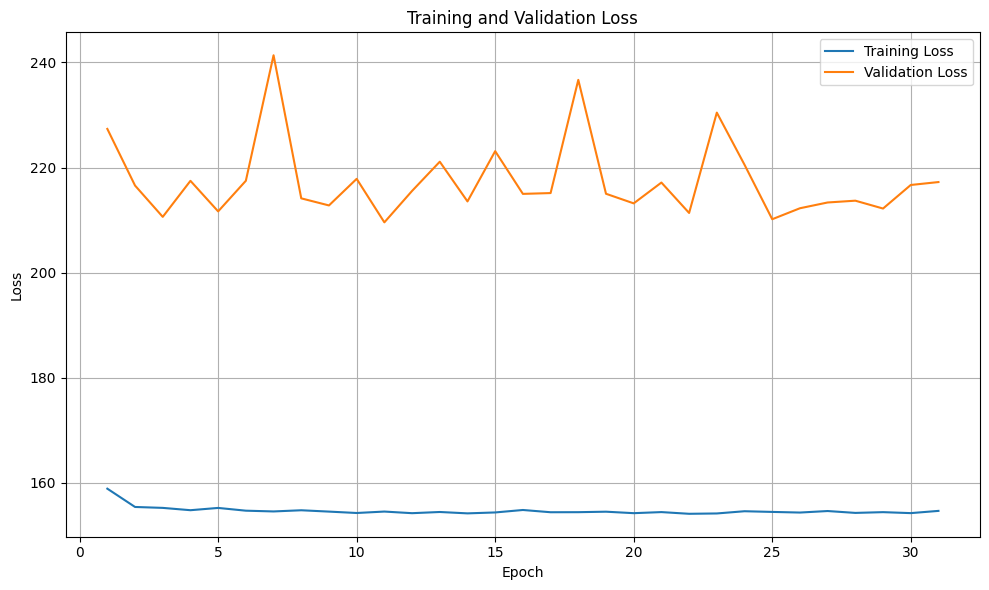

In [70]:
# Extract loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Find best (lowest) loss values and their epochs
best_train = min(train_loss)
best_val = min(val_loss)
print(f'Best training loss: {best_train}')
print(f'Best val loss: {best_val}')
# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

38/38 [==============================] - 0s 3ms/step
Test MAE: 11.55


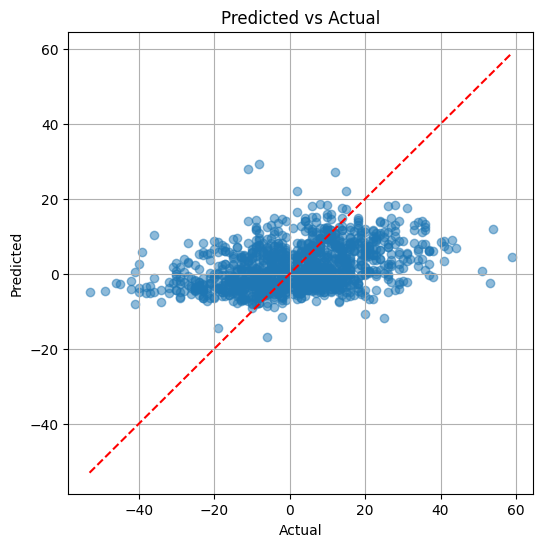

In [71]:
from sklearn.metrics import mean_absolute_error

# Predict on test set
y_pred = model.predict(X_test)

# Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(True)
plt.show()

In [72]:
print(f"Actual std: {np.std(y_test):.2f}")
print(f"Predicted std: {np.std(y_pred):.2f}")


Actual std: 15.86
Predicted std: 5.84


In [86]:
print(y_pred[0:5])

ff_test[ff_test['GAME_ID']=='0022401230']
# comparison_df = ff_test.drop(['SEASON_ID', 'TEAM_ID', 'TEAM_NAME', ''])
# comparison_df

[[-2.465712  ]
 [ 0.39115423]
 [ 2.536441  ]
 [-2.1571765 ]
 [ 6.4891195 ]]


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_TEAM_ABBREVIATION,OPP_PTS,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg,PT_DIFF
68279,2024,1610612745,HOU,Houston Rockets,0022401230,2024-12-14,L,240,96,0,3.0,112.72,13.88,35.48,22.52,8.76,5.64,12.56,41.32,93.92,11.72,35.88,18.36,23.8,20.24,OKC,111,115.791667,10.666667,33.083333,26.0,12.166667,6.375,11.041667,43.208333,92.916667,14.0,40.0,15.375,19.083333,20.958333,-15


# Compare with Sportsbook
Using a python library that webscrapes odds from sbrodds. I will use these odds to check the effectiveness of my model. Could start with over under, probably simplest to compare with what I have.

In [97]:
# Get odds data
from sbrscrape import Scoreboard
from datetime import date, timedelta

# list of dates on which the nba has games
# could use my prediction dataset

def get_odds_from(date: date.day) -> pd.DataFrame:
    sb = Scoreboard(date=date, sport='NBA')
    games = sb.games

    # Flatten nested dictionaries
    df = pd.json_normalize(games, sep='_')
    return df

exhibition_date = date(2024, 12, 14)
odds_df = get_odds_from(exhibition_date)
odds_df.head(4)

,date,status,home_team,home_team_loc,home_team_abbr,home_team_rank,away_team,away_team_loc,away_team_abbr,away_team_rank,home_score,away_score,home_spread_betmgm,home_spread_fanduel,home_spread_caesars,home_spread_bet365,home_spread_draftkings,home_spread_bet_rivers_ny,home_spread_odds_betmgm,home_spread_odds_fanduel,home_spread_odds_caesars,home_spread_odds_bet365,home_spread_odds_draftkings,home_spread_odds_bet_rivers_ny,away_spread_betmgm,away_spread_fanduel,away_spread_caesars,away_spread_bet365,away_spread_draftkings,away_spread_bet_rivers_ny,away_spread_odds_betmgm,away_spread_odds_fanduel,away_spread_odds_caesars,away_spread_odds_bet365,away_spread_odds_draftkings,away_spread_odds_bet_rivers_ny,under_odds_betmgm,under_odds_fanduel,under_odds_caesars,under_odds_bet365,under_odds_draftkings,under_odds_bet_rivers_ny,over_odds_betmgm,over_odds_fanduel,over_odds_caesars,over_odds_bet365,over_odds_draftkings,over_odds_bet_rivers_ny,total_betmgm,total_fanduel,total_caesars,total_bet365,total_draftkings,total_bet_rivers_ny,home_ml_betmgm,home_ml_fanduel,home_ml_caesars,home_ml_bet365,home_ml_draftkings,home_ml_bet_rivers_ny,away_ml_betmgm,away_ml_fanduel,away_ml_caesars,away_ml_bet365,away_ml_draftkings,away_ml_bet_rivers_ny
0,2024-12-14T21:30:00+00:00,Final,Milwaukee Bucks,Milwaukee,MIL,-1,Atlanta Hawks,Atlanta,ATL,-1,110,102,-3.5,-3.5,-3.5,-3.5,-3.5,-3.5,-110,-110,-115,-110,-108,-112,3.5,3.5,3.5,3.5,3.5,3.5,-110,-110,-105,-110,-112,-112,-105,-110,-110,-110,-108,-113,-115,-110,-110,-110,-112,-110,232.5,233.0,233,233,234,233,-165,-166,-189,-165,-166,-165,140,140,158,140,140,138
1,2024-12-15T01:30:00+00:00,Final,Oklahoma City Thunder,Oklahoma City,OKC,-1,Houston Rockets,Houston,HOU,-1,111,96,-5.5,-5.0,-5.5,-5.5,-5.5,-6.0,-110,-112,-105,-110,-112,-108,5.5,5.0,5.5,5.5,5.5,6.0,-110,-108,-115,-110,-108,-115,-110,-112,-115,-110,-112,-109,-110,-108,-105,-110,-108,-114,214.5,214.5,215,215,215,215,-225,-215,-238,-245,-230,-225,185,180,196,200,190,180


In [ ]:
# Define attribute groups you want to average
attribute_groups = [
    'home_spread', 'home_spread_odds',
    'away_spread', 'away_spread_odds',
    'under_odds', 'over_odds',
    'total', 'home_ml', 'away_ml'
]

# Compute averages across sportsbooks
for group in attribute_groups:
    # Select all columns that belong to the current group
    cols = [col for col in df.columns if col.startswith(f"{group}_")]
    # Compute row-wise mean
    df[f'{group}_avg'] = df[cols].mean(axis=1)

# Show resulting DataFrame with just the averages
average_cols = [col for col in df.columns if col.endswith('_avg')]
df.head(1)

,date,status,home_team,home_team_loc,home_team_abbr,home_team_rank,away_team,away_team_loc,away_team_abbr,away_team_rank,home_score,away_score,home_spread_betmgm,home_spread_fanduel,home_spread_caesars,home_spread_bet365,home_spread_draftkings,home_spread_bet_rivers_ny,home_spread_odds_betmgm,home_spread_odds_fanduel,home_spread_odds_caesars,home_spread_odds_bet365,home_spread_odds_draftkings,home_spread_odds_bet_rivers_ny,away_spread_betmgm,away_spread_fanduel,away_spread_caesars,away_spread_bet365,away_spread_draftkings,away_spread_bet_rivers_ny,away_spread_odds_betmgm,away_spread_odds_fanduel,away_spread_odds_caesars,away_spread_odds_bet365,away_spread_odds_draftkings,away_spread_odds_bet_rivers_ny,under_odds_betmgm,under_odds_fanduel,under_odds_caesars,under_odds_bet365,under_odds_draftkings,under_odds_bet_rivers_ny,over_odds_betmgm,over_odds_fanduel,over_odds_caesars,over_odds_bet365,over_odds_draftkings,over_odds_bet_rivers_ny,total_betmgm,total_fanduel,total_caesars,total_bet365,total_draftkings,total_bet_rivers_ny,home_ml_betmgm,home_ml_fanduel,home_ml_caesars,home_ml_bet365,home_ml_draftkings,home_ml_bet_rivers_ny,away_ml_betmgm,away_ml_fanduel,away_ml_caesars,away_ml_bet365,away_ml_draftkings,away_ml_bet_rivers_ny,home_spread_avg,home_spread_odds_avg,away_spread_avg,away_spread_odds_avg,under_odds_avg,over_odds_avg,total_avg,home_ml_avg,away_ml_avg
0,2025-05-01T23:30:00+00:00,Final,Detroit Pistons,Detroit,DET,-1,New York Knicks,New York,NY,-1,113,116,-1.5,-1.5,-1,-1,-1.5,-1.5,-105,-106,-110,-110,-110,-113,1.5,1.5,1,1,1.5,1.5,-115,-114,-110,-110,-110,-108,-105,-110,-115,-110,-112,-112,-115,-110,-105,-110,-108,-109,212.5,213,212.5,213,213.0,213.5,-120,-118,-115,-115,-118,-122,100,100,-105,-105,-102,104,-59.011905,-109.0,-58.934524,-111.166667,-110.666667,-109.5,212.916667,-118.0,-1.333333


In [ ]:
avg_cols = [col for col in df.columns if col.endswith('_avg')]
non_sportsbook_cols = [col for col in df.columns
                       if not any(col.startswith(f"{group}_") for group in attribute_groups)]

df_cleaned = df[average_cols + non_sportsbook_cols]
df.head(1)

,date,status,home_team,home_team_loc,home_team_abbr,home_team_rank,away_team,away_team_loc,away_team_abbr,away_team_rank,home_score,away_score,home_spread_betmgm,home_spread_fanduel,home_spread_caesars,home_spread_bet365,home_spread_draftkings,home_spread_bet_rivers_ny,home_spread_odds_betmgm,home_spread_odds_fanduel,home_spread_odds_caesars,home_spread_odds_bet365,home_spread_odds_draftkings,home_spread_odds_bet_rivers_ny,away_spread_betmgm,away_spread_fanduel,away_spread_caesars,away_spread_bet365,away_spread_draftkings,away_spread_bet_rivers_ny,away_spread_odds_betmgm,away_spread_odds_fanduel,away_spread_odds_caesars,away_spread_odds_bet365,away_spread_odds_draftkings,away_spread_odds_bet_rivers_ny,under_odds_betmgm,under_odds_fanduel,under_odds_caesars,under_odds_bet365,under_odds_draftkings,under_odds_bet_rivers_ny,over_odds_betmgm,over_odds_fanduel,over_odds_caesars,over_odds_bet365,over_odds_draftkings,over_odds_bet_rivers_ny,total_betmgm,total_fanduel,total_caesars,total_bet365,total_draftkings,total_bet_rivers_ny,home_ml_betmgm,home_ml_fanduel,home_ml_caesars,home_ml_bet365,home_ml_draftkings,home_ml_bet_rivers_ny,away_ml_betmgm,away_ml_fanduel,away_ml_caesars,away_ml_bet365,away_ml_draftkings,away_ml_bet_rivers_ny,home_spread_avg,home_spread_odds_avg,away_spread_avg,away_spread_odds_avg,under_odds_avg,over_odds_avg,total_avg,home_ml_avg,away_ml_avg
0,2025-05-01T23:30:00+00:00,Final,Detroit Pistons,Detroit,DET,-1,New York Knicks,New York,NY,-1,113,116,-1.5,-1.5,-1,-1,-1.5,-1.5,-105,-106,-110,-110,-110,-113,1.5,1.5,1,1,1.5,1.5,-115,-114,-110,-110,-110,-108,-105,-110,-115,-110,-112,-112,-115,-110,-105,-110,-108,-109,212.5,213,212.5,213,213.0,213.5,-120,-118,-115,-115,-118,-122,100,100,-105,-105,-102,104,-59.011905,-109.0,-58.934524,-111.166667,-110.666667,-109.5,212.916667,-118.0,-1.333333


# Reflections on project as of turning in assignment
I am pleased with the amount of work I accomplished given the time constraints. I was able to try two different models with some hyperparameter tuning. Need to look back at my machine learning notes to design a better architecture. I think we did a project with LSTMs. I do think the dataset was just lacking the necessary information to make great predictions. I need to get the odds data to compare it with. I did not truly finish the evaluation stage of my project without it. I can still do it. Could I use the y_test I already have? Compare that with the odds data for the season. Obtain an odds dataset for over/under team points.


# TODO:
Figure out the home team chosen by the sportsbook for all the exhbition games and inseason tournament finales


# Combined player statistics model
What raw data can I acquire?
Player statistics, starting lineup, injury report. Velocity for starting lineup and injury report. When are they announced? 
Game logs for player statistics
Does the API offer statistics for a specific date or will I have to derive them?
Add layers of abstraction

# Player statistics model
Would it be easier to model individual player points? For prop bets   
A simpler problem then team as a whole. One player can go off but a lot of times it will be due to changes in the lineup  
Include the combined stats of the other starters
